# Welfare Bot - Risk Level Classification

Tässä notebookissa käytän luokittelumallia ennustamaan käyttäjän riskitasoa ('risk_level') hyvinvointimittareiden perusteella.
Tavoitteena on harjoitella supervised machine learning -menetelmää ja arvioida mallin tuloksia confusion matrix -visualisoinnin avulla.

In [31]:
import pandas as pd # data manipulation
import matplotlib.pyplot as plt # data visualization

from sklearn.model_selection import train_test_split # for splitting the data into training and testing sets
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

In [ ]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv")
data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.890,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.980,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.670,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,0.79,0.91,2.79,7.765,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.250,low


In [ ]:
data = data.dropna() # poistaa kaikki rivit, joissa on puuttuvia arvoja
data.isnull().sum() # tarkistaa, onko datassa vielä puuttuvia arvoja

date                0
user_name           0
email               0
mood_score          0
sleep_score         0
food_score          0
hydration_score     0
medication_score    0
social_score        0
overall_score       0
risk_level          0
dtype: int64

## Feature selection

Valitsen mallille hyvinvointimittarit, joiden perusteella malli yrittää ennustaa käyttäjän riskitason.

Target-muuttuja on 'risk_level'.

In [ ]:
features = [ #  mallin syötteeksi käytettävät ominaisuudet
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score",
    "overall_score"
]

X = data[features]
y = data["risk_level"]

## Datan jakaminen

Jaan datan training ja testidataan. 
Training-dataa käytetään mallin kouluttamiseen ja testidataa mallin arviointiin.
Näin voin tarkistaa, kuinka hyvin malli toimii datalla, jota se ei ole nähnyt koulutuksen aikana.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% datasta testaukseen, 80% koulutukseen
    random_state=42 # satunnaisuuden hallinta, jotta tulokset ovat toistettavissa
)

## Decision Tree mallin kouluttaminen

Tässä vaiheessa käytän Decision Tree Classifier mallia riskitason ennustamiseen.
Decision Tree on luokittelumalli, joka tekee päätöksiä jakamalla dataa eri sääntöjen perusteella.
Mallin tavoitteena on oppia, millaiset hyvinvointimittarit liittyvät eri riskitasoihin.

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4, # rajoittaa puun syvyyden, jotta malli ei opi liikaa yksityiskohtia (overfitting)
    random_state=42 # satunnaisuuden hallinta, jotta tulokset ovat toistettavissa
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predictions

Tässä vaiheessa käytän koulutettua Decision Tree mallia ennustamaan testidatan riskitasoja.
Mallin ennusteita verrataan todellisiin riskitasoihin, jotta voidaan arvioida mallin onnistumista.

In [37]:
predictions = model.predict(X_test)

## Mallin arviointi

Tässä vaiheessa arvioin luokittelumallin tuloksia.
Käytän arviointiin: accuracy score, classification report ja confusion matrix
Näiden avulla voidaan nähdä, kuinka hyvin malli ennusti eri riskitasoja.

In [ ]:
accuracy = accuracy_score(y_test, predictions) # laskee mallin tarkkuuden vertaamalla testidatan oikeita luokkia mallin ennustamiin luokkiin

print(f"Accuracy: {accuracy:.2f}") # tulostaa tarkkuuden prosentteina, pyöristettynä kahden desimaalin tarkkuudella

print(classification_report(y_test, predictions)) # tulostaa tarkemman raportin mallin suorituskyvystä, joka sisältää mm. precision, recall ja f1-score -mittarit kullekin luokalle

Accuracy: 1.00
              precision    recall  f1-score   support

        high       1.00      1.00      1.00         3
         low       1.00      1.00      1.00        48
      medium       1.00      1.00      1.00        29

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## Confusion matrix

Confusion matrix näyttää, kuinka usein todellinen riskitaso ja mallin ennustama riskitaso osuivat yhteen.
Se auttaa näkemään mitkä riskitasot malli tunnisti oikein, missä riskitasoissa malli teki virheitä, sekoittiko malli esimerkiksi medium ja highriskitasoja keskenään

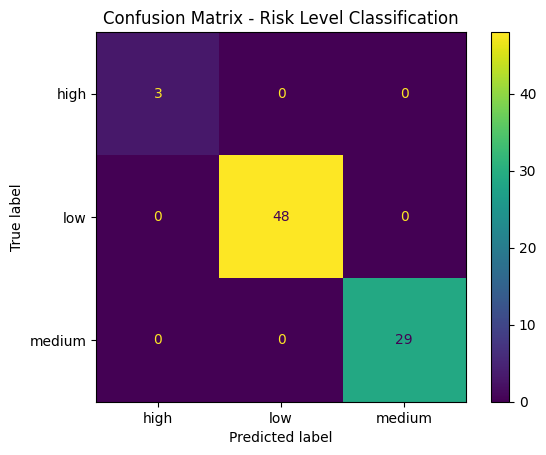

In [ ]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_) # laskee sekaannusmatriisin, joka näyttää, kuinka 
                                                     # monta kertaa malli ennusti oikein tai väärin kunkin luokan osalta

display = ConfusionMatrixDisplay(
    confusion_matrix=cm, # sekaannusmatriisi, joka näytetään kuvana
    display_labels=model.classes_ 
)

display.plot()

plt.title("Confusion Matrix - Risk Level Classification")
plt.show()

## Confusion matrix interpretation

Confusion matrixin perusteella Decision Tree -malli pystyi luokittelemaan riskitasot erittäin tarkasti tässä datasetissä.

Mallin ennusteet vastasivat täysin todellisia riskitasoja:
- kaikki high-risk havainnot tunnistettiin oikein
- kaikki medium-risk havainnot tunnistettiin oikein
- kaikki low-risk havainnot tunnistettiin oikein

Tulokset viittaavat siihen, että hyvinvointimittareiden ja riskitasojen välillä oli selkeä yhteys tässä aineistossa.
Mallin korkea tarkkuus voi kuitenkin myös tarkoittaa, että datasetti on melko yksinkertainen tai hyvin tasapainoinen.
Todellisessa hyvinvointidatassa riskitilanteet voivat olla monimutkaisempia, joten käytännön ympäristössä mallin toimintaa tulisi arvioida suuremmalla ja monipuolisemmalla aineistolla.